In [16]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [17]:


# Download latest version
folder_path = kagglehub.dataset_download("ameythakur20/unsupervisedlearning")

print("Path to dataset files:", folder_path)

Path to dataset files: /home/kabuga/.cache/kagglehub/datasets/ameythakur20/unsupervisedlearning/versions/1


In [18]:
all_files = os.listdir(folder_path)
print("\n--- Files found inside this dataset ---")
for file in all_files:
    print(f"- {file}")


--- Files found inside this dataset ---
- Iris.csv


In [19]:
csv_file_name = 'Iris.csv'

In [20]:
csv_path = os.path.join(folder_path , csv_file_name)
df = pd.read_csv(csv_path)
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [21]:
df.shape

(150, 6)

In [22]:
# we identify the unique categories in the species column'

categories = df['Species'].unique()
categories

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [23]:
# To perform clustering we need to clean

true_labels = df['Species']
X = df.drop(columns = ['Id' , 'Species'])

print("==== Cleaned Features For Clustering======")
print(X.head())

==== Cleaned Features For Clustering======
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


In [24]:
# we instantiate our model

model = KMeans(n_clusters = 3) # we already know the number of clusters we need

# we fit the x features to our model

model.fit(X)

# we now use our model to predict the labels(y) = this are the species

labels = model.predict(X)

# print the labels(features)

print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


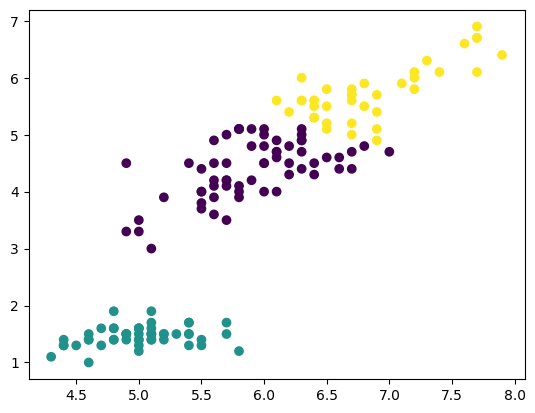

In [25]:
# plot a scatter plot

xs = X.iloc[:, 0]  # sepal length
ys = X.iloc[:,2] # petal length

plt.scatter(xs ,ys , c = labels) # c = must be a sequence iof numbers
plt.show()

In [26]:
# The next question we answer is how do you know the number of clusters to insert.

# How is the clusters you have specified the most efficient

print("========EVALUATING A CLUSTERING=============")

========EVALUATING A CLUSTERING=============


In [27]:
# There are 2 ways we can evaluate a cluster(DETERMINE IF THE CLUSTER WE HAVE PICKED IS THE BEST)

# 1. Compare predictions against expectations using a crosstab
# 2. Measuring using inertia

# crosstab = this is a cross tabulation table (a truth matrix ) to cross reference the computers numbered labels(predictions) against actual names

# inertia = measures how far the values are from the centroids or har far the clusters are spread apart

# The more the clusters the lower the inertia which is good

# But a good model is one where we have a balance in clusters and inertia . Not too many clusters

In [28]:
# CROSS-TABLE

species = df['Species'] # this are the actual species(expectations)

# we already have the predictions stored in labels

# create a dataframe of the 2

cross_df = pd.DataFrame({'labels' : labels , 'species' : species})

cross_df

,labels,species
0,1,Iris-setosa
1,1,Iris-setosa
2,1,Iris-setosa
3,1,Iris-setosa
4,1,Iris-setosa
...,...,...
145,2,Iris-virginica
146,0,Iris-virginica
147,2,Iris-virginica
148,2,Iris-virginica


In [29]:
# we create a cross tab of the 2
ct = pd.crosstab(cross_df['labels'] , cross_df['species'])
print(ct)

# model did fairly good. Predicted species: Iris-setosa and Iris-virginica well
                        # Struggled with Iris-veriscolor

species  Iris-setosa  Iris-versicolor  Iris-virginica
labels                                               
0                  0               48              14
1                 50                0               0
2                  0                2              36


In [38]:
# INERTIA

clusters = range(1 , 6)
inertia = []

for n in clusters:
    model_2 = KMeans(n_clusters = n)
    model_2.fit_predict(X)
    inertia.append(model_2.inertia_)
    print(inertia)

# Inertia is ranging within 78.94

[680.8244000000001]
[680.8244000000001, 152.36870647733903]
[680.8244000000001, 152.36870647733903, 78.94084142614602]
[680.8244000000001, 152.36870647733903, 78.94084142614602, 57.47327326549492]
[680.8244000000001, 152.36870647733903, 78.94084142614602, 57.47327326549492, 46.535582051282056]


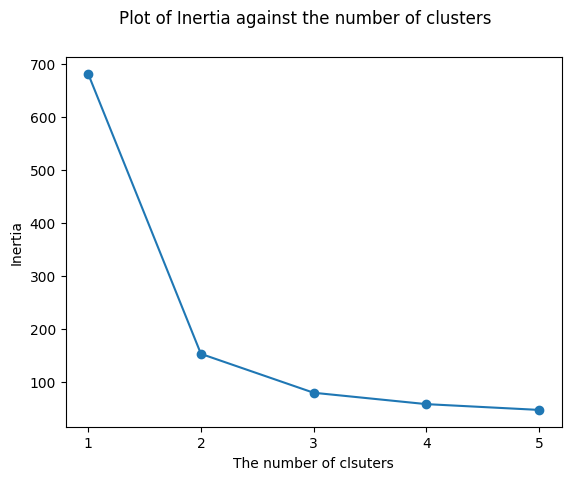

In [40]:
# we can plot this and see if 3 was a good pick

# we pick = a cluster which is at the elbow of the inertia plot

plt.plot(clusters , inertia , "-o") #clusters = x-axis and inertia = y-axis
plt.xlabel("The number of clsuters")
plt.ylabel("Inertia")
plt.xticks(clusters)
plt.suptitle("Plot of Inertia against the number of clusters")
plt.show()